# Enstrophy convergence

For a single barotropic simulation, detect $t_s$ from the global enstrophy series, take the diagnostic $D(t_s, M)$ (time-mean zonal-mean of $u$ over the post-spinup window) as the long-run reference, and plot the cos-lat-weighted relative L2 error of $D(t_s, t_s+i)$ against $i$. Mark the convergence offset $i_c$ at which the error first drops below CONVERGENCE_THRESHOLD and stays below for HOLD consecutive steps; the absolute convergence index is $t_c = t_s + i_c$.

All computations come from `ml.diagnostics`: `compute_enstrophy`, `find_spinup_time`, `compute_time_mean_zonal_mean`, `zonal_mean_convergence_errors`, `find_zonal_mean_convergence_time`.

In [1]:
SIM_DIRS = [
    "../../output/barotropic_stirring-T85/simulations/0",
    "../../output/barotropic_stirring-T85/simulations/111"
]

SPINUP_WINDOW = 8
SPINUP_HOLD = 3
SPINUP_TOLERANCE = 0.10

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from dataclasses import dataclass

plt.rcParams["figure.dpi"] = 120

from ml.cmd.rotating_globe import load_data
from ml.diagnostics import (
    mean_enstrophy, find_spinup_time
)

In [3]:
@dataclass
class SimData:
    name: str
    dataset: xr.Dataset
    enstrophy: np.ndarray

sims: list[SimData] = []
for sim_dir in SIM_DIRS:
    dataset = load_data(sim_dir)
    vorticities = dataset.vor.values
    lats = dataset.lat.values
    enstrophy = mean_enstrophy(vorticities, lats)
    sims.append(SimData(sim_dir.split("/")[-1], dataset, enstrophy))

TypeError: find_spinup_time() got an unexpected keyword argument 'tolerance_mean'

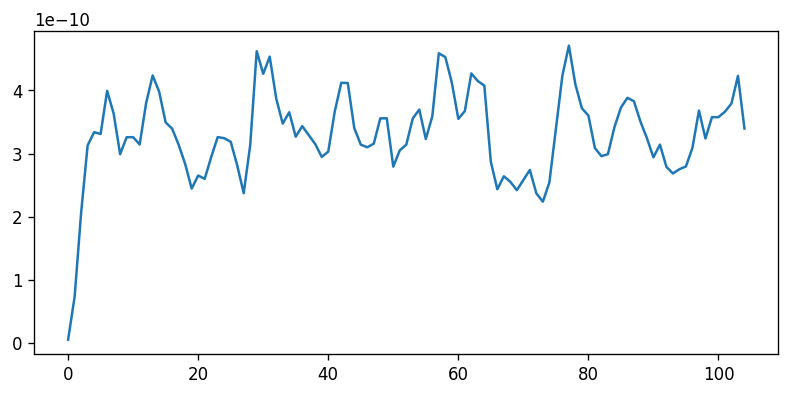

In [ ]:

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, sim_data in enumerate(sims):
    color = colors[i % len(colors)]
    ax.plot(sim_data.enstrophy, label=f"sim {sim_data.name}", color=color)
    t_s = find_spinup_time(sim_data.enstrophy)
    if t_s is not None:
        ax.axvline(t_s, color=color, linestyle="--", linewidth=1.2, label=f"sim {sim_data.name} $t_s={t_s}$")
    else:
        print(f"t_s is null for {sim_data.name}")
ax.set_title("Enstrophy over time")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Enstrophy")
ax.legend()
